# Mean-Reversion Pairs Trading Strategy

Limit order book tick data (10-second intervals), Nov 2019 – Dec 2020.  
We construct a spread between two instruments, test for stationarity via ADF,  
and evaluate a z-score mean-reversion strategy out-of-sample.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("final_data_10s.csv")
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
df.head()

,X_BID,X_BID_VOL,X_ASK,X_ASK_VOL,Y_BID,Y_BID_VOL,Y_ASK,Y_ASK_VOL
Time,,,,,,,,
2019-11-18 08:00:00,106340.0,15.0,106348.0,11.0,105200.0,9.0,105210.0,19.0
2019-11-18 08:00:10,106312.0,6.0,106320.0,9.0,105180.0,5.0,105190.0,13.0
2019-11-18 08:00:20,106312.0,7.0,106320.0,12.0,105170.0,32.0,105180.0,1.0
2019-11-18 08:00:30,106336.0,22.0,106340.0,1.0,105190.0,10.0,105200.0,19.0
2019-11-18 08:00:40,106352.0,2.0,106356.0,4.0,105200.0,29.0,105220.0,24.0


## 1. Mid-Price Construction

We estimate each instrument's fair value as the midpoint of its best bid and ask.  
This filters out the bid-ask bounce that would add noise to the spread.

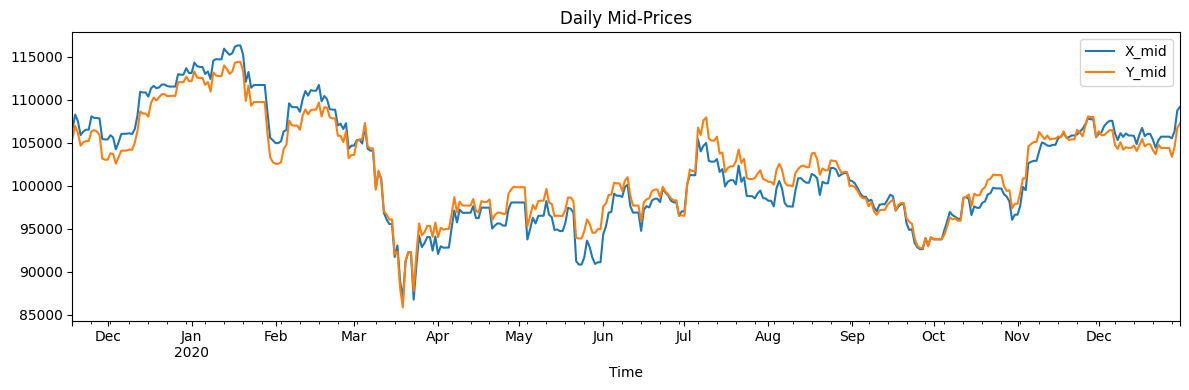

In [2]:
df["X_mid"] = (df["X_ASK"] + df["X_BID"]) / 2
df["Y_mid"] = (df["Y_ASK"] + df["Y_BID"]) / 2

df[["X_mid", "Y_mid"]].resample("1D").last().dropna().plot(
    title="Daily Mid-Prices", figsize=(12, 4)
)
plt.tight_layout()

## 2. Train / Test Split

We split the data at the end of June 2020.  
All model parameters (hedge ratio, rolling statistics) are estimated  
on the training set only and then **frozen** for the test period.

In [3]:
TRAIN_END = "2020-06-30"
TEST_START = "2020-07-01"

train_df = df[:TRAIN_END]
test_df  = df[TEST_START:]

print(f"Train: {train_df.index.min().date()} → {train_df.index.max().date()}  "
      f"({len(train_df):,} rows)")
print(f"Test:  {test_df.index.min().date()} → {test_df.index.max().date()}  "
      f"({len(test_df):,} rows)")

Train: 2019-11-18 → 2020-06-30  (407,252 rows)
Test:  2020-07-01 → 2020-12-31  (330,487 rows)


## 3. Cointegration Test (Engle–Granger)

We run the Engle–Granger test on daily closing mid-prices during the  
training period to check whether X and Y share a long-run equilibrium.

In [4]:
from statsmodels.tsa.stattools import coint

X_train_daily = train_df["X_mid"].resample("1D").last().dropna()
Y_train_daily = train_df["Y_mid"].resample("1D").last().dropna()

score, p_value, _ = coint(X_train_daily, Y_train_daily)
print(f"Engle–Granger p-value: {p_value:.4f}")
print("Cointegrated at 5%?" , "Yes" if p_value < 0.05 else "No")

Engle–Granger p-value: 0.1778
Cointegrated at 5%? No


## 4. Spread Construction

We fit an OLS regression of Y on X during training to get a hedge ratio  
**and intercept**. The spread is defined as:

$$\text{spread}_t = Y_t - \beta \, X_t - \alpha$$

Including the intercept centres the training spread around zero,  
which is important because our z-score thresholds are symmetric.

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_df[["X_mid"]], train_df["Y_mid"])

hedge_ratio = model.coef_[0]
intercept   = model.intercept_

print(f"Hedge ratio (β): {hedge_ratio:.6f}")
print(f"Intercept   (α): {intercept:.2f}")

# Apply to the FULL dataset (parameters are frozen from training)
df["spread"] = df["Y_mid"] - hedge_ratio * df["X_mid"] - intercept

Hedge ratio (β): 0.823655
Intercept   (α): 17938.94


## 5. Stationarity Test (ADF) on Training Spread

We run the Augmented Dickey–Fuller test on the **training** spread only.  
A low p-value gives us evidence that the spread is mean-reverting  
during the period we estimated our parameters on.

In [6]:
from statsmodels.tsa.stattools import adfuller

train_spread_daily = df["spread"][:TRAIN_END].resample("1D").last().dropna()
adf_stat, adf_pval, *_ = adfuller(train_spread_daily)

print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value:   {adf_pval:.6f}")
print("Stationary at 5%?", "Yes" if adf_pval < 0.05 else "No")

ADF statistic: -2.8650
ADF p-value:   0.049572
Stationary at 5%? Yes


## 6. Z-Score Construction (Frozen Parameters)

We compute the rolling mean and standard deviation of the spread  
over the training period, then **freeze** the final values.  
The test-period z-score is calculated using only these frozen parameters,  
so the strategy never sees future data.

Frozen mean: 543.28
Frozen std:  660.06


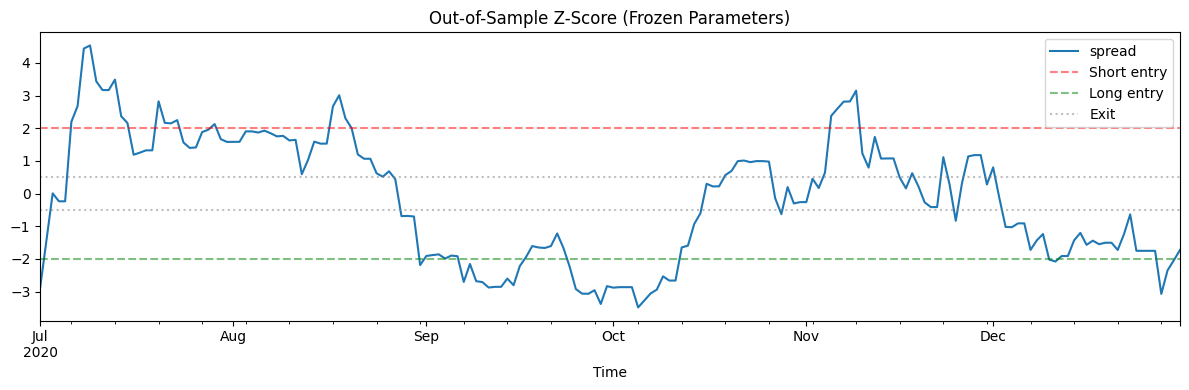

In [7]:
WINDOW = 60  # trading days

spread_daily = df["spread"].resample("1D").last().dropna()
train_spread = spread_daily[:TRAIN_END]

# Compute rolling stats on training data and freeze the last values
frozen_mean = train_spread.rolling(WINDOW, min_periods=WINDOW).mean().iloc[-1]
frozen_std  = train_spread.rolling(WINDOW, min_periods=WINDOW).std().iloc[-1]

print(f"Frozen mean: {frozen_mean:.2f}")
print(f"Frozen std:  {frozen_std:.2f}")

# Z-score for the test period using frozen parameters
test_spread = spread_daily[TEST_START:]
z_score = (test_spread - frozen_mean) / frozen_std

z_score.plot(title="Out-of-Sample Z-Score (Frozen Parameters)", figsize=(12, 4))
plt.axhline( 2, color="red",   ls="--", alpha=0.5, label="Short entry")
plt.axhline(-2, color="green", ls="--", alpha=0.5, label="Long entry")
plt.axhline( 0.5, color="grey", ls=":",  alpha=0.5, label="Exit")
plt.axhline(-0.5, color="grey", ls=":",  alpha=0.5)
plt.legend()
plt.tight_layout()

## 7. Signal Generation

| Condition | Action |
|-----------|--------|
| z < −2    | **Long** the spread (expect reversion upward) |
| z > +2    | **Short** the spread (expect reversion downward) |
| \|z\| < 0.5 | **Exit** (spread has reverted) |

Signals are forward-filled to hold the position until an exit fires.

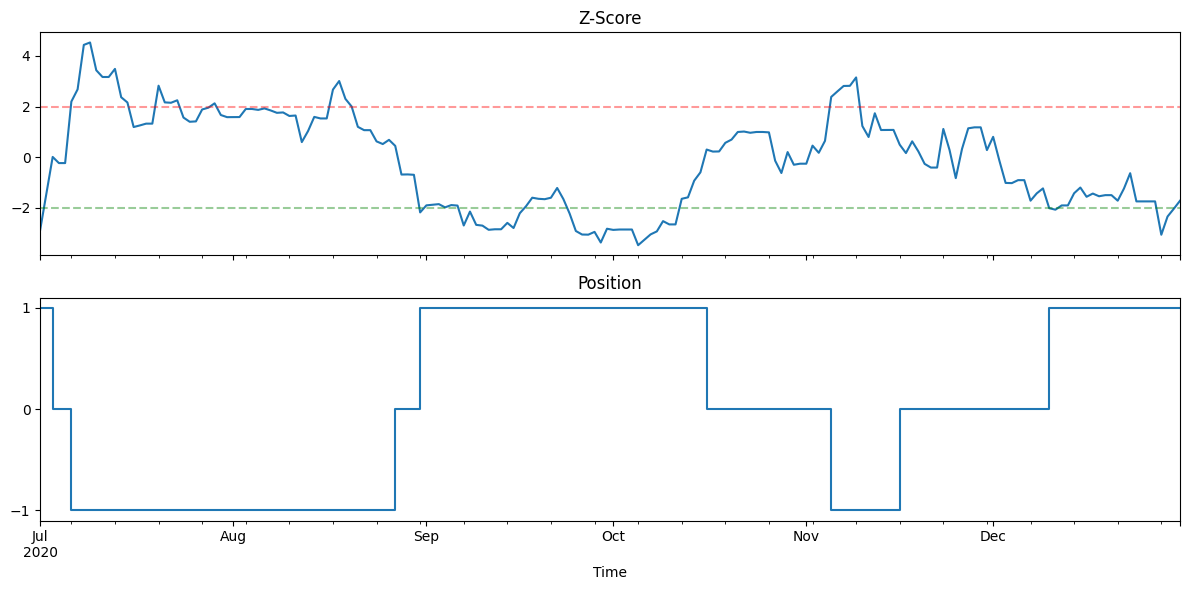

In [8]:
long_entry  = z_score < -2
short_entry = z_score >  2
exit_signal = z_score.abs() < 0.5

positions = pd.Series(np.nan, index=z_score.index)
positions[long_entry]  =  1
positions[short_entry] = -1
positions[exit_signal] =  0
positions = positions.ffill().fillna(0)

# Visualise
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
z_score.plot(ax=axes[0], title="Z-Score")
axes[0].axhline( 2, color="red",   ls="--", alpha=0.4)
axes[0].axhline(-2, color="green", ls="--", alpha=0.4)

positions.plot(ax=axes[1], title="Position", drawstyle="steps-post")
axes[1].set_yticks([-1, 0, 1])
plt.tight_layout()

## 8. Backtest

`positions.shift(1)` ensures we trade on the day **after** observing the signal,  
preventing look-ahead bias. Returns are computed as the daily spread change  
divided by the notional value of the pair.

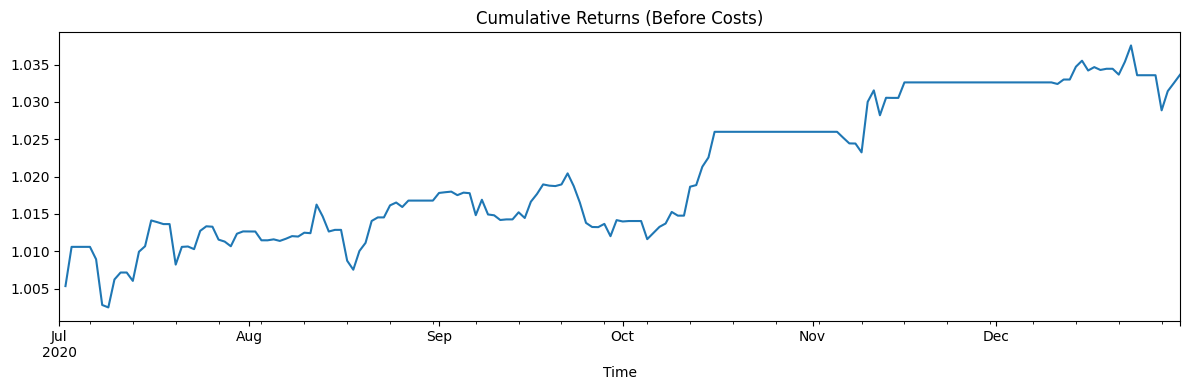

In [9]:
# Daily prices for the test period
X_daily = df["X_mid"].resample("1D").last().dropna()
Y_daily = df["Y_mid"].resample("1D").last().dropna()

# Daily spread PnL and notional
spread_pnl = spread_daily.diff()
notional = Y_daily + abs(hedge_ratio) * X_daily

spread_returns = spread_pnl / notional.shift(1)

# Strategy returns (lagged positions → no look-ahead)
strategy_returns = (positions.shift(1) * spread_returns).reindex(z_score.index)

cumulative = (1 + strategy_returns).cumprod()
cumulative.plot(title="Cumulative Returns (Before Costs)", figsize=(12, 4))
plt.tight_layout()

## 9. Performance Metrics

In [10]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
max_dd = (cumulative / cumulative.cummax() - 1).min()
total_return = cumulative.iloc[-1] - 1

in_market = strategy_returns[positions.shift(1) != 0]
hit_rate = (in_market > 0).mean()

n_trades = (positions.diff().abs().fillna(0) > 0).sum()

print(f"Total Return: {total_return:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")
print(f"Hit Rate:     {hit_rate:.2%}")
print(f"Num Trades:   {n_trades}")

Total Return: 3.36%
Sharpe Ratio: 1.82
Max Drawdown: -0.86%
Hit Rate:     48.12%
Num Trades:   8


## 10. Transaction Costs

We apply 1 bps (0.01%) per leg on each trade event.  
`positions.diff().abs()` captures both entries/exits (Δ = 1) and flips (Δ = 2),  
so flips naturally incur double the cost. The `.fillna(0)` prevents the first  
row's `NaN` from propagating into the net returns.

Total Return (net): 3.20%
Sharpe (net):       1.74
Max Drawdown (net): -0.86%


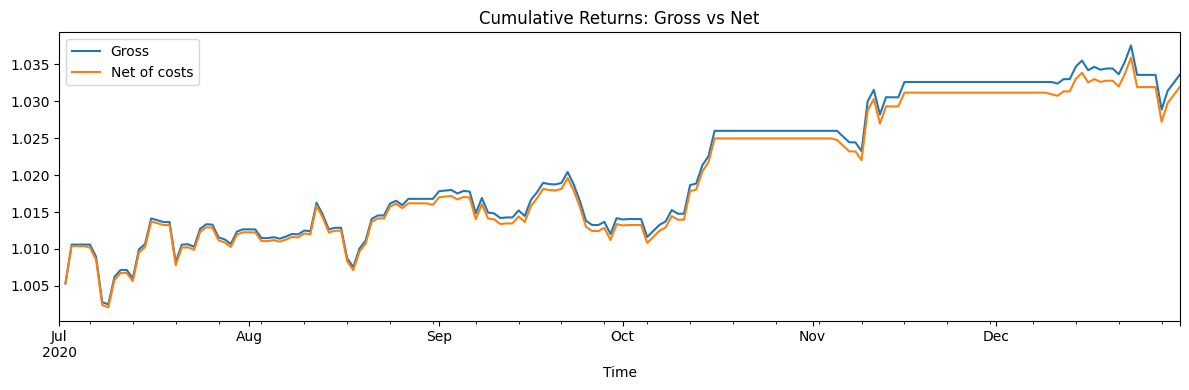

In [11]:
COST_BPS = 0.0001  # 1 bps per leg

trades = positions.diff().abs().fillna(0)
cost_impact = trades * COST_BPS * 2  # × 2 for both legs of the pair

strategy_returns_net = strategy_returns - cost_impact

cumulative_net = (1 + strategy_returns_net).cumprod()

sharpe_net = strategy_returns_net.mean() / strategy_returns_net.std() * np.sqrt(252)
total_return_net = cumulative_net.iloc[-1] - 1
max_dd_net = (cumulative_net / cumulative_net.cummax() - 1).min()

print(f"Total Return (net): {total_return_net:.2%}")
print(f"Sharpe (net):       {sharpe_net:.2f}")
print(f"Max Drawdown (net): {max_dd_net:.2%}")

# Compare
fig, ax = plt.subplots(figsize=(12, 4))
cumulative.plot(ax=ax, label="Gross")
cumulative_net.plot(ax=ax, label="Net of costs")
ax.set_title("Cumulative Returns: Gross vs Net")
ax.legend()
plt.tight_layout()